# 05 — National Analysis

**Workflow**
1. **Clip** all datasets to a country folder (`data/countries/{ISO3}/`) — run once
2. **Inspect** clipped data (maps, coverage)
3. **Single-epoch analysis** — concentration curve, CI, quintile breakdown
4. **Year-by-year time series** — CI and mean loss over time
5. **Epoch comparison** — overlay concentration curves across decades

To use a different population dataset, drop a GeoTIFF into `data/countries/{ISO3}/`
and set `POPULATION_FILE` in the configuration cell.

In [13]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import geopandas as gpd
import rasterio
import rasterio.mask
from rasterio.warp import reproject, Resampling
from shapely.geometry import mapping
import yaml
from tqdm.notebook import tqdm

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from scripts.inequality import (
    calculate_CI, calculate_concentration_curve,
    prepare_arrays
)
from scripts.raster_utils import get_country_geometry

with open(ROOT / 'config' / 'config.yaml') as f:
    config = yaml.safe_load(f)

DATA = ROOT / 'data'
print('Ready.')

Task was destroyed but it is pending!
task: <Task pending name='Task-128' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Mark.DESKTOP-UFHIN6T\anaconda3\envs\howden_heat\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-129' coro=<Kernel.shell_main() running at C:\Users\Mark.DESKTOP-UFHIN6T\anaconda3\envs\howden_heat\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Mark.DESKTOP-UFHIN6T\anaconda3\envs\howden_heat\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Mark.DESKTOP-UFHIN6T\anaconda3\envs\howden_heat\Lib\site-packages\yaml\scanner.py:286: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for level in list(self.possible_simple_keys):
Task was destroyed but it is pending!
task: <Task pending name='Task-129' coro=<Kernel.shell_main() running at C:\Users\Mark.DESKTOP-UFHIN6T\anaconda3\envs\howden_heat\Lib\site-packages\i

Ready.


---
## Configuration
Edit this cell before running anything else.

In [29]:
# --- Country ---
ISO3 = 'KEN'

# --- WBGT dataset ---
# Options: 'wbgt' | 'wbgt_baseline' | 'wbgt_future_2030_ssp245' | 'wbgt_future_2030_ssp585'
#          'wbgt_future_2050_ssp245' | 'wbgt_future_2050_ssp585'
WBGT_DATASET = 'wbgt_future_2050_ssp585'

# --- Paths (used for clipping only — leave as-is unless data moved) ---
GLOBAL_POP_PATH = ROOT / config['data']['population']
GLOBAL_RWI_PATH = ROOT / config['data']['rwi']
BOUNDARIES_PATH = ROOT / config['data']['boundaries']
ANNUAL_SRC_DIR  = DATA / 'processed' / 'annual' / WBGT_DATASET

# --- Country folder ---
COUNTRY_DIR      = DATA / 'countries' / ISO3
WBGT_COUNTRY_DIR = COUNTRY_DIR / WBGT_DATASET

print(f'Country:      {ISO3}')
print(f'WBGT dataset: {WBGT_DATASET}')
print(f'Country dir:  {COUNTRY_DIR}')

Country:      KEN
WBGT dataset: wbgt_future_2050_ssp585
Country dir:  E:\Projects\Howden\Heatwaves\howden_heat\data\countries\KEN


---
## Step 1 — Clip datasets to country folder

Run once per country / WBGT dataset. Skips files that already exist unless `FORCE_CLIP = True`.

In [30]:
FORCE_CLIP = False

COUNTRY_DIR.mkdir(parents=True, exist_ok=True)
WBGT_COUNTRY_DIR.mkdir(parents=True, exist_ok=True)

geom = get_country_geometry(str(BOUNDARIES_PATH), ISO3)


def clip_and_save(src_path: Path, dst_path: Path, geometry, force: bool = False) -> None:
    """Clip a raster to a geometry (reprojects geometry to raster CRS) and save."""
    if dst_path.exists() and not force:
        return
    with rasterio.open(src_path) as src:
        raster_crs = src.crs
        geo_s = gpd.GeoSeries([geometry], crs='EPSG:4326')
        clip_geom = [mapping(geo_s.to_crs(raster_crs).iloc[0])]
        out_image, out_transform = rasterio.mask.mask(src, clip_geom, crop=True)
        out_meta = src.meta.copy()
        out_meta.update({
            'height': out_image.shape[1],
            'width':  out_image.shape[2],
            'transform': out_transform,
            'compress': 'lzw',
        })
    with rasterio.open(dst_path, 'w', **out_meta) as dst:
        dst.write(out_image)


# Population
pop_dst = COUNTRY_DIR / 'population.tif'
clip_and_save(GLOBAL_POP_PATH, pop_dst, geom, force=FORCE_CLIP)
status = 'clipped' if not pop_dst.exists() or FORCE_CLIP else 'already exists'
print(f'Population:  {status}')

# RWI
rwi_dst = COUNTRY_DIR / 'rwi.tif'
clip_and_save(GLOBAL_RWI_PATH, rwi_dst, geom, force=FORCE_CLIP)
status = 'clipped' if not rwi_dst.exists() or FORCE_CLIP else 'already exists'
print(f'RWI:         {status}')

# Annual WBGT productivity rasters
annual_src_files = sorted(ANNUAL_SRC_DIR.glob('productivity_loss_*.tif'))
if not annual_src_files:
    print(f'WARNING: No annual rasters found in {ANNUAL_SRC_DIR}')
else:
    to_clip = [f for f in annual_src_files
               if not (WBGT_COUNTRY_DIR / f.name).exists() or FORCE_CLIP]
    print(f'WBGT:        clipping {len(to_clip)} / {len(annual_src_files)} rasters...')
    for f in tqdm(to_clip, desc='Clipping WBGT'):
        clip_and_save(f, WBGT_COUNTRY_DIR / f.name, geom, force=FORCE_CLIP)

print('\nCountry folder contents:')
for f in sorted(COUNTRY_DIR.rglob('*.tif')):
    size_mb = f.stat().st_size / 1e6
    print(f'  {str(f.relative_to(COUNTRY_DIR)):<55} {size_mb:.1f} MB')

Population:  already exists
RWI:         already exists
WBGT:        clipping 0 / 34 rasters...


Clipping WBGT: 0it [00:00, ?it/s]


Country folder contents:
  KEN_ghs-pop.tif                                         86.4 MB
  ken_pop_2025_CN_100m_R2025A_v1.tif                      69.8 MB
  ken_pop_2025_CN_1km_R2025A_UA_v1.tif                    1.6 MB
  population.tif                                          1.7 MB
  rwi.tif                                                 0.2 MB
  wbgt\productivity_loss_1980.tif                         0.1 MB
  wbgt\productivity_loss_1981.tif                         0.1 MB
  wbgt\productivity_loss_1982.tif                         0.1 MB
  wbgt\productivity_loss_1983.tif                         0.1 MB
  wbgt\productivity_loss_1984.tif                         0.1 MB
  wbgt\productivity_loss_1985.tif                         0.1 MB
  wbgt\productivity_loss_1986.tif                         0.1 MB
  wbgt\productivity_loss_1987.tif                         0.1 MB
  wbgt\productivity_loss_1988.tif                         0.1 MB
  wbgt\productivity_loss_1989.tif                         0.1 

---
## Step 2 — Load and align country data

In [31]:
# Show available population files so you can pick one
print('Population files in country folder:')
for f in sorted(COUNTRY_DIR.glob('*.tif')):
    if 'population' in f.name or 'pop' in f.name.lower():
        print(f'  {f.name}')

wbgt_files = sorted(WBGT_COUNTRY_DIR.glob('productivity_loss_*.tif'))
years      = sorted([int(f.stem.split('_')[-1]) for f in wbgt_files])
print(f'\nAnnual WBGT rasters: {len(wbgt_files)}  ({min(years)}–{max(years)})')

Population files in country folder:
  KEN_ghs-pop.tif
  ken_pop_2025_CN_100m_R2025A_v1.tif
  ken_pop_2025_CN_1km_R2025A_UA_v1.tif
  population.tif

Annual WBGT rasters: 34  (1983–2016)


In [32]:
# Choose population file
POPULATION_FILE = 'population.tif'

In [33]:
def read_raster(path: Path) -> tuple[np.ndarray, dict]:
    with rasterio.open(path) as src:
        arr    = src.read(1).astype(np.float32)
        nodata = src.nodata
        meta   = src.meta.copy()
    if nodata is not None:
        arr[arr == nodata] = np.nan
    return arr, meta


def resample_to(src_arr, src_meta, ref_meta, method=Resampling.bilinear):
    """
    Resample src_arr onto the grid defined by ref_meta.
    Always reprojects unconditionally — handles any combination of CRS,
    resolution, and extent differences (including a custom pop raster that
    is slightly bigger or smaller than the other datasets).
    Areas outside the source extent are filled with NaN.
    """
    dest = np.full((ref_meta['height'], ref_meta['width']), np.nan, dtype=np.float32)
    reproject(source=src_arr, destination=dest,
              src_transform=src_meta['transform'], src_crs=src_meta['crs'],
              dst_transform=ref_meta['transform'], dst_crs=ref_meta['crs'],
              resampling=method, src_nodata=np.nan, dst_nodata=np.nan)
    return dest


def epoch_mean(wbgt_dir: Path, start: int, end: int) -> tuple[np.ndarray, dict] | None:
    """Average clipped annual rasters for years [start, end]."""
    files = [wbgt_dir / f'productivity_loss_{y}.tif'
             for y in range(start, end + 1)
             if (wbgt_dir / f'productivity_loss_{y}.tif').exists()]
    if not files:
        return None, None
    with rasterio.open(files[0]) as src:
        shape = (src.height, src.width)
        meta  = src.meta.copy()
    acc   = np.zeros(shape, np.float64)
    count = np.zeros(shape, np.int32)
    for f in files:
        with rasterio.open(f) as src:
            arr = src.read(1).astype(np.float64)
        valid = ~np.isnan(arr)
        acc[valid]   += arr[valid]
        count[valid] += 1
    return np.where(count > 0, acc / count, np.nan).astype(np.float32), meta


# Load population — defines the reference grid for all other layers
pop, pop_meta = read_raster(COUNTRY_DIR / POPULATION_FILE)

# Load RWI and always resample to pop grid (handles any CRS/extent mismatch)
rwi, rwi_meta = read_raster(COUNTRY_DIR / 'rwi.tif')
rwi[rwi < -10] = np.nan   # RWI nodata (-999 and interpolation artefacts)
rwi = resample_to(rwi, rwi_meta, pop_meta, Resampling.nearest)

print(f'Population grid: {pop.shape}  ({POPULATION_FILE})')
print(f'RWI grid after resampling: {rwi.shape}')
print(f'Total population: {np.nansum(pop[pop > 0]):,.0f}')
print(f'RWI valid cells:  {np.sum(~np.isnan(rwi)):,}  '
      f'({100 * np.sum(~np.isnan(rwi)) / rwi.size:.1f}% of pop grid)')

Population grid: (1167, 960)  (population.tif)
RWI grid after resampling: (1167, 960)
Total population: 56,936,864
RWI valid cells:  203,857  (18.2% of pop grid)


In [34]:
# --- Set epoch for single-epoch analysis (Steps 3–4) ---
EPOCH_START = years[0]
EPOCH_END   = years[-1]
# -------------------------------------------------------

risk_arr, risk_meta = epoch_mean(WBGT_COUNTRY_DIR, EPOCH_START, EPOCH_END)
risk = resample_to(risk_arr, risk_meta, pop_meta)

arrays = prepare_arrays(pop, rwi, risk)
if arrays is None:
    raise ValueError('Insufficient valid data — check that pop, RWI and risk overlap.')
pop_f, rwi_f, risk_f = arrays

ci        = calculate_CI(pop_f, rwi_f, risk_f)
mean_loss = float(np.average(risk_f, weights=pop_f))

print(f'Epoch {EPOCH_START}–{EPOCH_END}  |  {WBGT_DATASET}')
print(f'  CI:           {ci:.3f}')
print(f'  Mean loss:    {mean_loss:.4f}')
print(f'  Population:   {pop_f.sum():,.0f}')

Epoch 1983–2016  |  wbgt_future_2050_ssp585
  CI:           -0.111
  Mean loss:    0.0432
  Population:   55,063,896


C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_35140\137947096.py:45: RuntimeWarning: invalid value encountered in divide
  return np.where(count > 0, acc / count, np.nan).astype(np.float32), meta


---
## Step 3 — Spatial maps

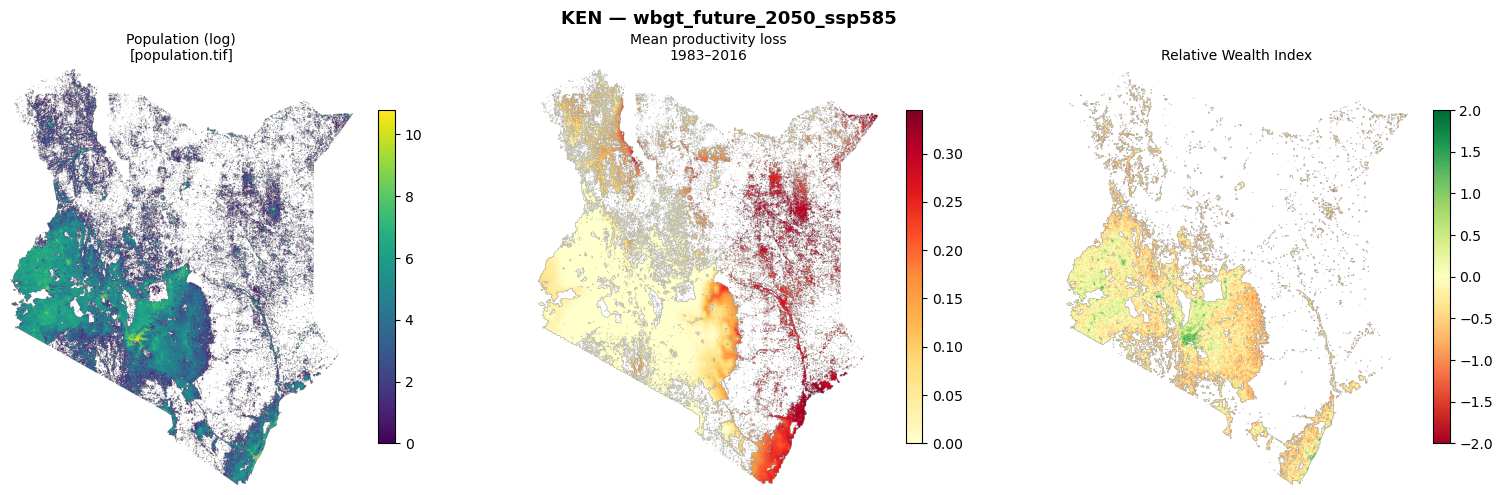

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pop_d  = np.where(pop  > 0,               pop,  np.nan)
risk_d = np.where(pop  > 0,               risk, np.nan)
rwi_d  = np.where((pop > 0) & ~np.isnan(rwi), rwi,  np.nan)

for ax, arr, cmap, vmin, vmax, title in [
    (axes[0], np.log1p(pop_d), 'viridis', None, None, f'Population (log)\n[{POPULATION_FILE}]'),
    (axes[1], risk_d,          'YlOrRd',  0,    None, f'Mean productivity loss\n{EPOCH_START}–{EPOCH_END}'),
    (axes[2], rwi_d,           'RdYlGn', -2,    2,    'Relative Wealth Index'),
]:
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.suptitle(f'{ISO3} — {WBGT_DATASET}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4 — Concentration curve and quintile breakdown

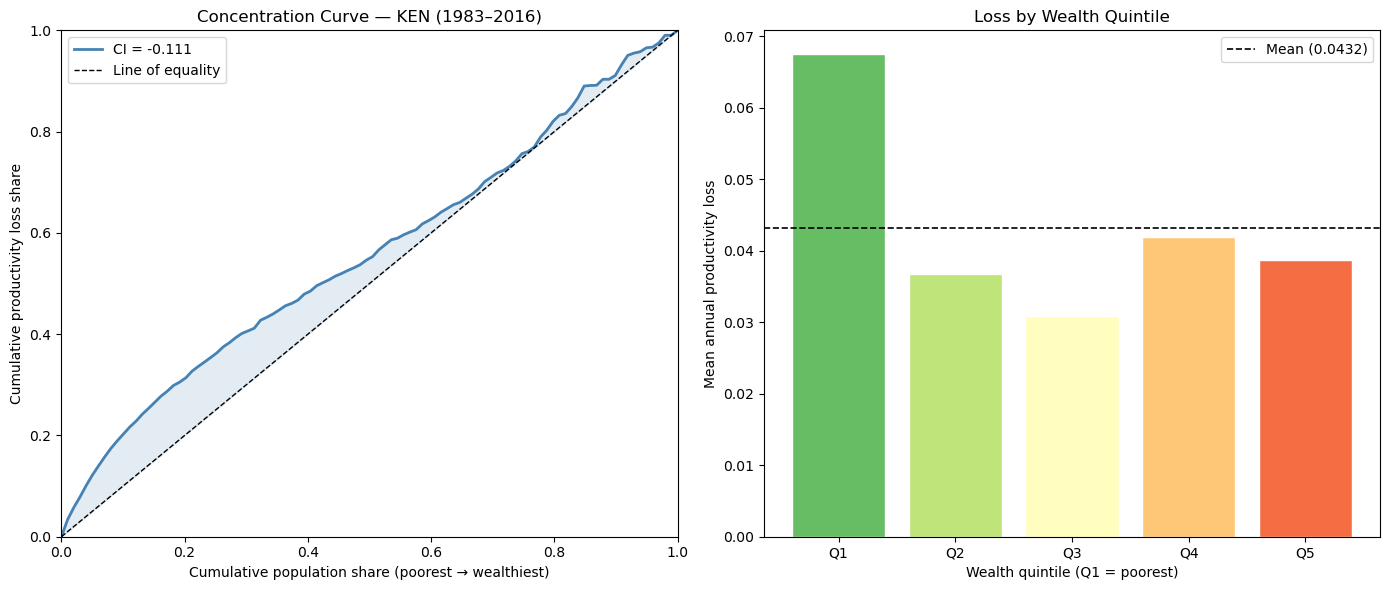

 Q     loss
Q1 0.067479
Q2 0.036748
Q3 0.030915
Q4 0.041957
Q5 0.038672


In [36]:
cum_pop, cum_risk = calculate_concentration_curve(pop_f, rwi_f, risk_f)

# Quintile breakdown
df = pd.DataFrame({'pop': pop_f, 'rwi': rwi_f, 'risk': risk_f}).sort_values('rwi')
df['cum_pop'] = df['pop'].cumsum()
tp = df['pop'].sum()
qdf = pd.DataFrame([
    {'Q': f'Q{q}', 'loss': np.average(
        df[(df['cum_pop'] > (q-1)/5*tp) & (df['cum_pop'] <= q/5*tp)]['risk'],
        weights=df[(df['cum_pop'] > (q-1)/5*tp) & (df['cum_pop'] <= q/5*tp)]['pop']
    )} for q in range(1, 6)
])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(cum_pop, cum_risk, color='steelblue', linewidth=2,
        label=f'CI = {ci:.3f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Line of equality')
ax.fill_between(cum_pop, cum_risk, cum_pop,
                alpha=0.15, color='steelblue' if ci < 0 else 'tomato')
ax.set_xlabel('Cumulative population share (poorest → wealthiest)')
ax.set_ylabel('Cumulative productivity loss share')
ax.set_title(f'Concentration Curve — {ISO3} ({EPOCH_START}–{EPOCH_END})')
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

ax = axes[1]
ax.bar(qdf['Q'], qdf['loss'],
       color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(qdf))),
       edgecolor='white')
ax.axhline(mean_loss, color='black', linewidth=1.2, linestyle='--',
           label=f'Mean ({mean_loss:.4f})')
ax.set_xlabel('Wealth quintile (Q1 = poorest)')
ax.set_ylabel('Mean annual productivity loss')
ax.set_title('Loss by Wealth Quintile')
ax.legend()

plt.tight_layout()
plt.show()
print(qdf.to_string(index=False))

---
## Step 5 — Year-by-year time series

Annual CI:   0%|          | 0/34 [00:00<?, ?it/s]

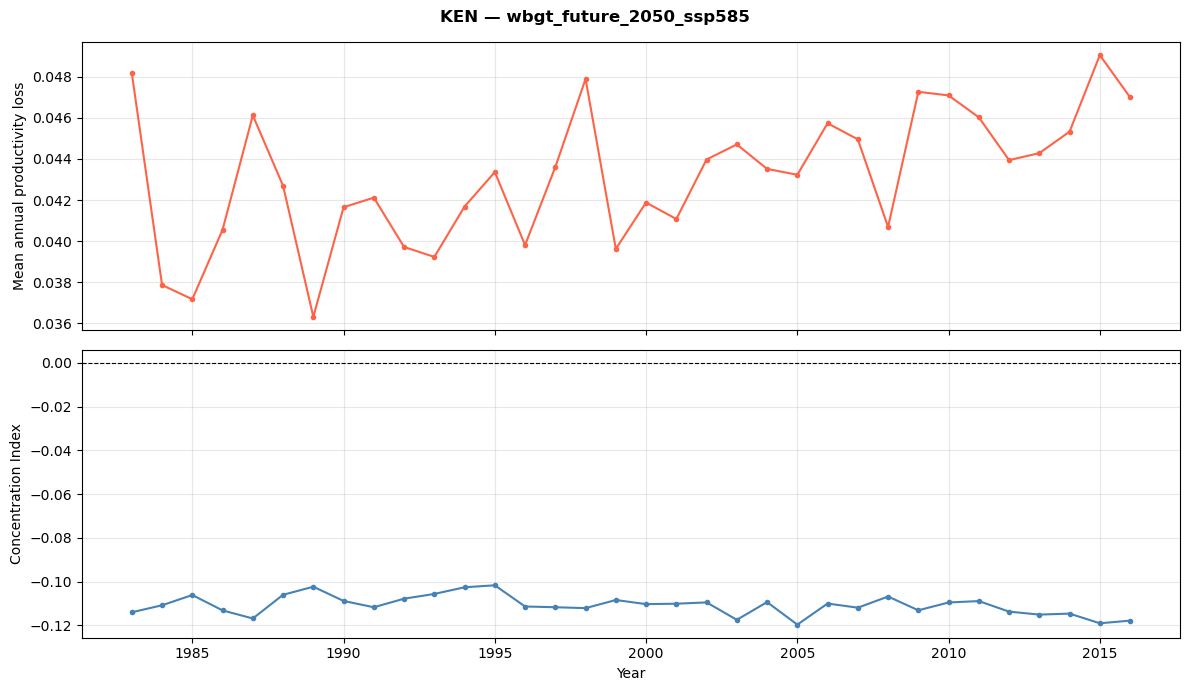

,year,CI,mean_loss
0,1983,-0.114034,0.048166
1,1984,-0.110834,0.037868
2,1985,-0.106148,0.037177
3,1986,-0.113185,0.040555
4,1987,-0.116873,0.046114
5,1988,-0.106052,0.042692
6,1989,-0.102349,0.036322
7,1990,-0.108861,0.041648
8,1991,-0.111740,0.042116
9,1992,-0.107820,0.039718


In [37]:
ts_records = []

for fpath in tqdm(wbgt_files, desc='Annual CI'):
    year = int(fpath.stem.split('_')[-1])
    risk_yr, risk_yr_meta = read_raster(fpath)
    risk_yr_res = resample_to(risk_yr, risk_yr_meta, pop_meta)
    arr = prepare_arrays(pop, rwi, risk_yr_res)
    if arr is None:
        continue
    p, w, r = arr
    ts_records.append({
        'year':      year,
        'CI':        calculate_CI(p, w, r),
        'mean_loss': float(np.average(r, weights=p)),
    })

ts_df = pd.DataFrame(ts_records).sort_values('year')

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(ts_df['year'], ts_df['mean_loss'], marker='o', markersize=3, color='tomato')
axes[0].set_ylabel('Mean annual productivity loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts_df['year'], ts_df['CI'], marker='o', markersize=3, color='steelblue')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Concentration Index')
axes[1].set_xlabel('Year')
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'{ISO3} — {WBGT_DATASET}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

ts_df

---
## Step 6 — Epoch comparison

Define as many epochs as you like. Each gets its own concentration curve.

C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_35140\137947096.py:45: RuntimeWarning: invalid value encountered in divide
  return np.where(count > 0, acc / count, np.nan).astype(np.float32), meta
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_35140\137947096.py:45: RuntimeWarning: invalid value encountered in divide
  return np.where(count > 0, acc / count, np.nan).astype(np.float32), meta
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_35140\137947096.py:45: RuntimeWarning: invalid value encountered in divide
  return np.where(count > 0, acc / count, np.nan).astype(np.float32), meta


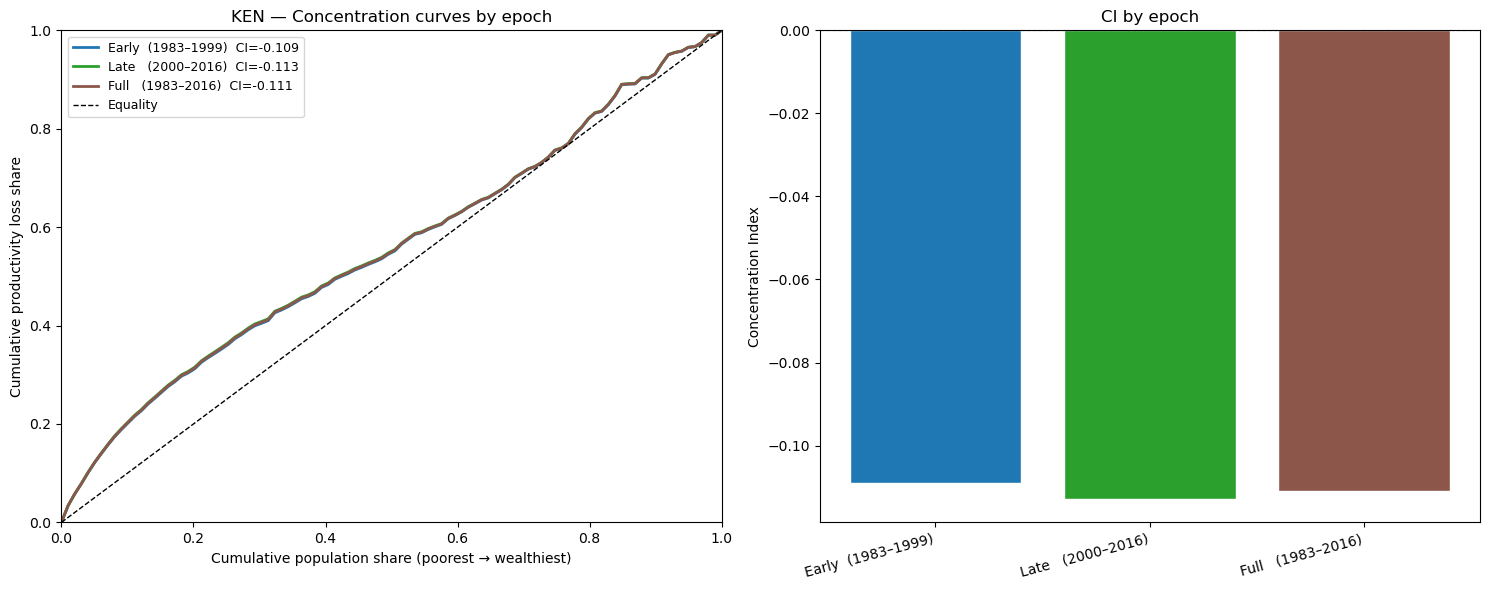

             Epoch        CI  Mean loss
Early  (1983–1999) -0.109089   0.041622
Late   (2000–2016) -0.112866   0.044686
Full   (1983–2016) -0.111045   0.043154


In [38]:
# --- Define epochs to compare ---
EPOCHS = {
    'Early  (1983–1999)': (1983, 1999),
    'Late   (2000–2016)': (2000, 2016),
    'Full   (1983–2016)': (1983, 2016),
}
# --------------------------------

colors = cm.tab10(np.linspace(0, 0.5, len(EPOCHS)))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
epoch_summary = []

for (label, (start, end)), color in zip(EPOCHS.items(), colors):
    r_arr, r_meta = epoch_mean(WBGT_COUNTRY_DIR, start, end)
    if r_arr is None:
        print(f'  {label}: no data')
        continue
    r_res = resample_to(r_arr, r_meta, pop_meta)
    arr   = prepare_arrays(pop, rwi, r_res)
    if arr is None:
        continue
    p, w, r = arr
    ep_ci   = calculate_CI(p, w, r)
    ep_loss = float(np.average(r, weights=p))
    cp, cr  = calculate_concentration_curve(p, w, r)
    epoch_summary.append({'Epoch': label.strip(), 'CI': ep_ci, 'Mean loss': ep_loss})

    axes[0].plot(cp, cr, color=color, linewidth=2,
                 label=f'{label.strip()}  CI={ep_ci:.3f}')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Equality')
axes[0].set_xlabel('Cumulative population share (poorest → wealthiest)')
axes[0].set_ylabel('Cumulative productivity loss share')
axes[0].set_title(f'{ISO3} — Concentration curves by epoch')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

ep_df = pd.DataFrame(epoch_summary)
x = np.arange(len(ep_df))
axes[1].bar(x, ep_df['CI'], color=colors[:len(ep_df)], edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ep_df['Epoch'], rotation=15, ha='right')
axes[1].set_ylabel('Concentration Index')
axes[1].set_title('CI by epoch')

plt.tight_layout()
plt.show()

print(ep_df.to_string(index=False))

---
## Step 7 — Baseline vs future concentration curves

Compare concentration curves across different WBGT datasets (e.g. observed baseline
vs climate scenario) on the same axes.

**Requires:** country-clipped rasters to exist in `data/countries/{ISO3}/{dataset}/`.
Run Step 1 for each dataset first if needed.

C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_35140\137947096.py:45: RuntimeWarning: invalid value encountered in divide
  return np.where(count > 0, acc / count, np.nan).astype(np.float32), meta
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_35140\137947096.py:45: RuntimeWarning: invalid value encountered in divide
  return np.where(count > 0, acc / count, np.nan).astype(np.float32), meta


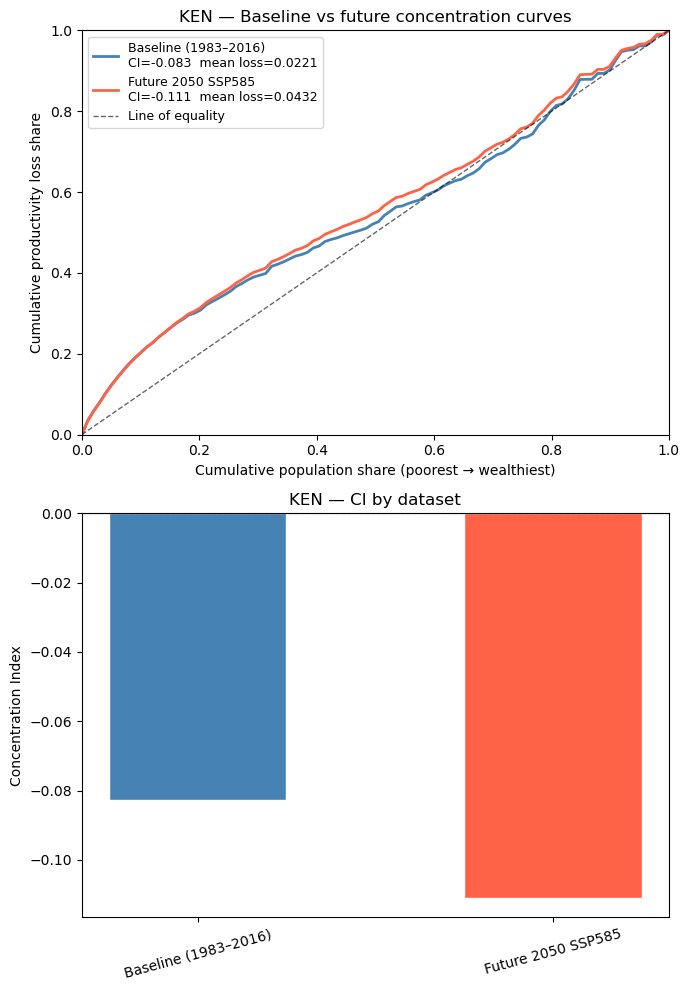

             Dataset        CI  Mean loss
Baseline (1983–2016) -0.082803   0.022140
  Future 2050 SSP585 -0.111045   0.043154


In [39]:
# --- Define datasets and epoch to compare ---
# Each entry: 'Label': ('dataset_folder_name', start_year, end_year)
COMPARE = {
    'Baseline (1983–2016)':       ('wbgt_baseline',          1983, 2016),
    'Future 2050 SSP585': ('wbgt_future_2050_ssp585', 1983, 2016),
}
COMPARE_COLORS = ['steelblue', 'tomato', 'forestgreen', 'darkorchid']
# --------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(7, 10))
summary = []

for (label, (dataset, start, end)), color in zip(COMPARE.items(), COMPARE_COLORS):
    wbgt_dir = COUNTRY_DIR / dataset
    if not wbgt_dir.exists():
        print(f'  {label}: folder not found — {wbgt_dir}')
        print(f'    Run Step 1 with WBGT_DATASET = {dataset!r} to clip rasters first.')
        continue

    r_arr, r_meta = epoch_mean(wbgt_dir, start, end)
    if r_arr is None:
        print(f'  {label}: no rasters found in {wbgt_dir} for {start}–{end}')
        continue

    r_res  = resample_to(r_arr, r_meta, pop_meta)
    arrays = prepare_arrays(pop, rwi, r_res)
    if arrays is None:
        print(f'  {label}: insufficient overlapping valid cells')
        continue

    p, w, r = arrays
    ep_ci   = calculate_CI(p, w, r)
    ep_loss = float(np.average(r, weights=p))
    cp, cr  = calculate_concentration_curve(p, w, r)
    summary.append({'Dataset': label, 'CI': ep_ci, 'Mean loss': ep_loss})

    # Concentration curve
    axes[0].plot(cp, cr, color=color, linewidth=2,
                 label=f'{label}\nCI={ep_ci:.3f}  mean loss={ep_loss:.4f}')

    # CI bar
    axes[1].bar(label, ep_ci, color=color, edgecolor='white', width=0.5)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Line of equality')
axes[0].fill_between([], [], [], alpha=0)   # spacer
axes[0].set_xlabel('Cumulative population share (poorest → wealthiest)')
axes[0].set_ylabel('Cumulative productivity loss share')
axes[0].set_title(f'{ISO3} — Baseline vs future concentration curves')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Concentration Index')
axes[1].set_title(f'{ISO3} — CI by dataset')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

if summary:
    print(pd.DataFrame(summary).to_string(index=False))

---
## Step 8 — Mean annual productivity loss by national wealth quintile per ADM2 region

Wealth quintiles are defined **nationally** (pixels ranked by RWI across the whole country),
then mean productivity loss is reported for each quintile within each ADM2 district.
Requires `data/boundaries/geoBoundaries_ADM2.shp` with columns `shapeName`, `shapeGroup` (ISO3), `shapeID`.

In [40]:
from rasterio.features import geometry_mask

# ── Step 8a: assign every valid pixel a national wealth quintile label (1–5) ──

# Valid pixels: positive population, RWI present, risk present
valid_2d = ~np.isnan(pop) & (pop > 0) & ~np.isnan(rwi) & ~np.isnan(risk)

# Flat indices keep the link back to 2D positions
flat_idx = np.where(valid_2d.ravel())[0]
p_flat   = pop.ravel()[flat_idx]
w_flat   = rwi.ravel()[flat_idx]

# Sort by RWI nationally and compute cumulative population
sort_ord  = np.argsort(w_flat, kind='stable')
cum_pop   = np.cumsum(p_flat[sort_ord])
total_pop = cum_pop[-1]

# Assign quintile labels in sorted order, then invert back to original order
q_labels_sorted = np.zeros(len(flat_idx), dtype=np.int8)
for q in range(1, 6):
    in_q = (cum_pop > (q - 1) / 5 * total_pop) & (cum_pop <= q / 5 * total_pop)
    q_labels_sorted[in_q] = q

q_labels = np.empty_like(q_labels_sorted)
q_labels[sort_ord] = q_labels_sorted  # invert the sort

# Store quintile assignment back in a 2D grid (0 = not valid)
quintile_raster = np.zeros(pop.shape, dtype=np.int8)
quintile_raster.ravel()[flat_idx] = q_labels

print('National quintile pixel counts:')
for q in range(1, 6):
    print(f'  Q{q}: {(quintile_raster == q).sum():,} pixels')

# ── Step 8b: for each ADM2, report mean loss per national quintile ─────────────

ADM2_PATH = ROOT / 'data' / 'boundaries' / 'geoBoundaries_ADM2.shp'

adm2 = gpd.read_file(ADM2_PATH, where=f"shapeGroup = '{ISO3}'")
adm2 = adm2.to_crs(pop_meta['crs'])
print(f'\nADM2 regions for {ISO3}: {len(adm2)}')

records = []
for _, row in tqdm(adm2.iterrows(), total=len(adm2), desc='ADM2'):
    spatial_mask = geometry_mask(
        [mapping(row.geometry)],
        transform=pop_meta['transform'],
        invert=True,
        out_shape=(pop_meta['height'], pop_meta['width']),
    )

    in_region = spatial_mask & valid_2d
    if in_region.sum() < 10:
        continue

    p_r = pop[in_region]
    r_r = risk[in_region]
    q_r = quintile_raster[in_region]

    rec = {
        'shapeName':  row['shapeName'],
        'shapeID':    row['shapeID'],
        'population': float(p_r.sum()),
        'mean_loss':  float(np.average(r_r, weights=p_r)),
    }
    for q in range(1, 6):
        in_q = q_r == q
        rec[f'Q{q}'] = float(np.average(r_r[in_q], weights=p_r[in_q])) if in_q.sum() >= 1 else np.nan
    records.append(rec)

adm2_loss_df = pd.DataFrame(records)
print(f'ADM2 regions with sufficient data: {len(adm2_loss_df)} / {len(adm2)}')
adm2_loss_df.to_csv('ADM2_future.csv')

National quintile pixel counts:
  Q1: 102,153 pixels
  Q2: 43,036 pixels
  Q3: 25,543 pixels
  Q4: 11,138 pixels
  Q5: 2,602 pixels

ADM2 regions for KEN: 314


ADM2:   0%|          | 0/314 [00:00<?, ?it/s]

ADM2 regions with sufficient data: 291 / 314
